In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from source.random_walk import generate_random_walk
from source.plot_tools import activity_map
from source.attractor_networks.grid_bump import ToroidBurakFiete2009

Ran warm up for 4599 steps
0.057610710969870124 0.5213989191810413


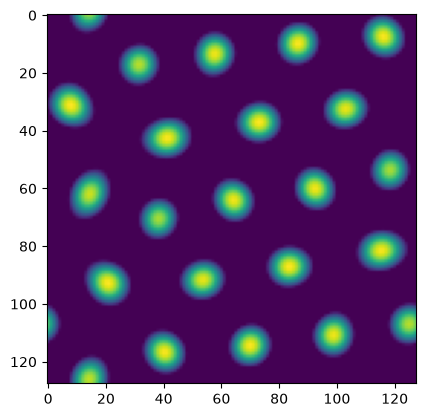

In [2]:
## Simulation parameters:
box_size = 1.5
dt = 0.5e-3
n = 128
tau = 10e-3
T = 500


net = ToroidBurakFiete2009(n = n,dt=dt,tau=tau, periodicity = 20)
net.warm_up()
print(np.mean(net.s),np.max(net.s))
plt.imshow(net.s)

In [ ]:
rng = np.random.default_rng(seed=0)

position, velocity, time = generate_random_walk(
    T=T, dt=dt, boxsize=box_size, rng=rng
)

n_steps = position.shape[0]
population_records = 1000
record_steps = np.linspace(1, n_steps - 1, population_records, dtype=int)

recorded_population = np.zeros((population_records, n, n))
recorded_sample_neuron = np.zeros(n_steps)

population_recording_index = 0
for step_iter in tqdm.tqdm(range(1, n_steps), "Running steps"):

    vx, vy = velocity[step_iter - 1, 0], velocity[step_iter - 1, 1]
    population_recording_index = 0

    for step_iter in tqdm.tqdm(range(1, n_steps), "Running steps"):
        vx, vy = velocity[step_iter - 1, 0], velocity[step_iter - 1, 1]
        net.step(vx,vy)

        if (
            population_recording_index < recorded_population.shape[0]
            and step_iter == record_steps[population_recording_index]
        ):
            recorded_population[population_recording_index] = net.s.copy()
            population_recording_index += 1

        recorded_sample_neuron[step_iter] = net.s[0, 0]

    recorded_sample_neuron[step_iter] = net.s[0, 0]

In [3]:
# np.save("simulation_data/recorded_sample_neuron.npy", recorded_sample_neuron)
# np.save("simulation_data/recorded_position.npy", position)
# np.save("simulation_data/recorded_time.npy", time)
# np.save("simulation_data/recorded_population.npy", recorded_population)
recorded_sample_neuron = np.load("simulation_data/recorded_sample_neuron.npy")
position = np.load("simulation_data/recorded_position.npy")
time = np.load("simulation_data/recorded_time.npy")
recorded_population = np.load("simulation_data/recorded_population.npy")

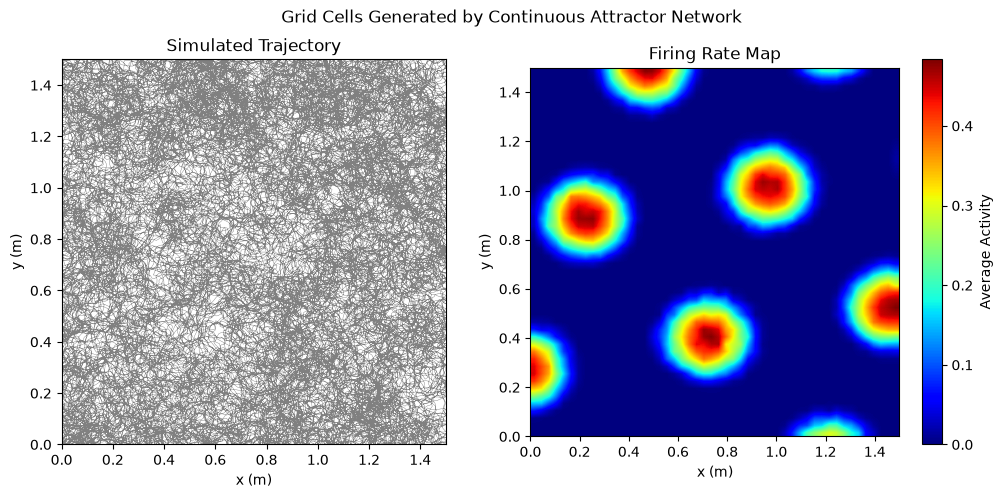

In [6]:
binned_activity, edges = activity_map(position, recorded_sample_neuron)
fig, ax = plt.subplots(
    1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": (1, 1.2)}
)
cb = ax[1].imshow(
    binned_activity, origin="lower", extent=[0, box_size, 0, box_size], cmap="jet",interpolation="bilinear",

)
ax[1].set_xlabel("x (m)")
ax[1].set_ylabel("y (m)")
ax[1].set_title("Firing Rate Map")
fig.colorbar(cb, ax=ax[1], label="Average Activity")

ax[0].set_title("Simulated Trajectory")
ax[0].plot(position[:,0], position[:,1], lw=0.3, color="gray")
ax[0].set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")
ax[0].set_xlim((0, box_size))
ax[0].set_ylim((0, box_size))
fig.suptitle("Grid Cells Generated by Continuous Attractor Network")
fig.savefig("plots/can_grid_cells.png")